# 02 — Preprocesado
**Proyecto:** NLP Disaster Tweets Classification  
**Curso:** Fundamentos de Deep Learning — Universidad de Antioquia  
**Autor:** Assandry Barón Rodríguez  

Este notebook implementa el **pipeline completo de preprocesamiento** de texto.
Lee los datos crudos, aplica la limpieza, tokeniza, genera las secuencias con
padding y guarda los artefactos listos para el entrenamiento.

---
**Contenido**
1. Configuración del entorno
2. Carga de datos crudos
3. Pipeline de limpieza de texto
4. Análisis post-limpieza
5. Tokenización y vocabulario
6. Padding de secuencias
7. División train / validación
8. Guardar artefactos preprocesados


## 1. Configuración del Entorno

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_PATH  = '/content/drive/MyDrive/NLP_Disaster_Tweets'
DATA_PATH  = os.path.join(BASE_PATH, 'data')
MODEL_PATH = os.path.join(BASE_PATH, 'models')

os.makedirs(MODEL_PATH, exist_ok=True)

print('Verificando datos crudos ...')
for f in ['train.csv', 'test.csv']:
    full   = os.path.join(DATA_PATH, f)
    status = '✅' if os.path.exists(full) else '❌  FALTA — sube los CSV a data/'
    print(f'  {status}  {f}')


Mounted at /content/drive
Verificando datos crudos ...
  ✅  train.csv
  ✅  test.csv


In [2]:
import re, pickle, warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection                 import train_test_split

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
print('✅ Imports correctos')


✅ Imports correctos


## 2. Carga de Datos Crudos

In [3]:
train_df = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_PATH, 'test.csv'))

print(f'Train : {train_df.shape}')
print(f'Test  : {test_df.shape}')
train_df.head(3)


Train : (7613, 5)
Test  : (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1


## 3. Pipeline de Limpieza de Texto

### Decisiones de diseño del pipeline

| Paso | Operación | Justificación |
|---|---|---|
| 1 | Lowercase | Reduce vocabulario (Fire = fire) |
| 2 | Eliminar URLs | No aportan semántica |
| 3 | Eliminar menciones @usuario | No generalizan |
| 4 | Normalizar hashtags | Conserva la palabra relevante |
| 5 | Eliminar números | Dígitos aislados no son informativos |
| 6 | Eliminar puntuación | Solo letras y espacios |
| 7 | Colapsar espacios | Normalización final |


In [4]:
def clean_text(text: str) -> str:
    """
    Pipeline de limpieza de texto para tweets en inglés.

    Parámetros
    ----------
    text : str — tweet crudo

    Retorna
    -------
    str — tweet limpio listo para tokenizar
    """
    if not isinstance(text, str):
        return ''

    # 1. Lowercase
    text = text.lower()
    # 2. Eliminar URLs (http / https / www)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    # 3. Eliminar menciones @usuario
    text = re.sub(r'@\w+', ' ', text)
    # 4. Normalizar hashtags (#fire → fire)
    text = re.sub(r'#(\w+)', r'\1', text)
    # 5. Eliminar números
    text = re.sub(r'\d+', ' ', text)
    # 6. Eliminar puntuación y caracteres no-ASCII
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 7. Colapsar espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Verificar con 5 ejemplos
print('Verificación del pipeline (5 ejemplos):\n')
for i in range(5):
    orig  = train_df['text'].iloc[i]
    clean = clean_text(orig)
    print(f'  ORIGINAL : {orig}')
    print(f'  LIMPIO   : {clean}')
    print()


Verificación del pipeline (5 ejemplos):

  ORIGINAL : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
  LIMPIO   : our deeds are the reason of this earthquake may allah forgive us all

  ORIGINAL : Forest fire near La Ronge Sask. Canada
  LIMPIO   : forest fire near la ronge sask canada

  ORIGINAL : All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
  LIMPIO   : all residents asked to shelter in place are being notified by officers no other evacuation or shelter in place orders are expected

  ORIGINAL : 13,000 people receive #wildfires evacuation orders in California 
  LIMPIO   : people receive wildfires evacuation orders in california

  ORIGINAL : Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school 
  LIMPIO   : just got sent this photo from ruby alaska as smoke from wildfires pours into a school



In [5]:
# Aplicar a train y test
train_df['text_clean'] = train_df['text'].apply(clean_text)
test_df['text_clean']  = test_df['text'].apply(clean_text)

# Detectar tweets vacíos post-limpieza
empty_train = (train_df['text_clean'] == '').sum()
empty_test  = (test_df['text_clean']  == '').sum()
print(f'Tweets vacíos post-limpieza — Train: {empty_train}  |  Test: {empty_test}')

# Si hay vacíos, reemplazar con token neutro
train_df['text_clean'] = train_df['text_clean'].replace('', 'unknown')
test_df['text_clean']  = test_df['text_clean'].replace('', 'unknown')

print('✅ Limpieza aplicada correctamente')


Tweets vacíos post-limpieza — Train: 0  |  Test: 0
✅ Limpieza aplicada correctamente


## 4. Análisis Post-Limpieza

In [6]:
train_df['word_len_clean'] = train_df['text_clean'].apply(lambda x: len(x.split()))

print('Estadísticas de longitud POST-limpieza (palabras):')
print(train_df.groupby('target')['word_len_clean'].describe().round(2))
print()

# Percentil 95 → guía para MAX_LEN
p95 = np.percentile(train_df['word_len_clean'], 95)
p99 = np.percentile(train_df['word_len_clean'], 99)
print(f'Percentil 95 de longitud: {p95:.0f} palabras')
print(f'Percentil 99 de longitud: {p99:.0f} palabras')
print(f'→ MAX_LEN recomendado: 50 (cubre el {(train_df["word_len_clean"] <= 50).mean()*100:.1f}% de tweets)')


Estadísticas de longitud POST-limpieza (palabras):
         count   mean   std  min   25%   50%   75%   max
target                                                  
0       4342.0  13.78  6.44  1.0   9.0  13.0  18.0  31.0
1       3271.0  13.95  5.33  1.0  10.0  14.0  18.0  33.0

Percentil 95 de longitud: 24 palabras
Percentil 99 de longitud: 28 palabras
→ MAX_LEN recomendado: 50 (cubre el 100.0% de tweets)


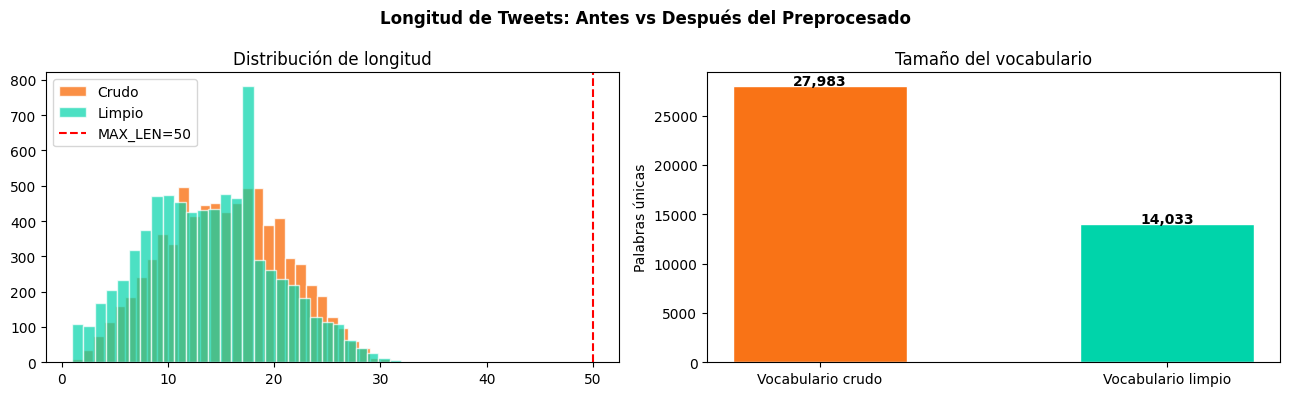

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Longitud de Tweets: Antes vs Después del Preprocesado', fontsize=12, fontweight='bold')

train_df['word_len_raw'] = train_df['text'].apply(lambda x: len(str(x).split()))

axes[0].hist(train_df['word_len_raw'],   bins=30, color='#f97316', alpha=0.8, label='Crudo',  edgecolor='white')
axes[0].hist(train_df['word_len_clean'], bins=30, color='#00d4aa', alpha=0.7, label='Limpio', edgecolor='white')
axes[0].axvline(50, color='red', ls='--', lw=1.5, label='MAX_LEN=50')
axes[0].set_title('Distribución de longitud'); axes[0].legend()

# Reducción de vocabulario
all_words_raw   = ' '.join(train_df['text']).lower().split()
all_words_clean = ' '.join(train_df['text_clean']).split()
axes[1].bar(['Vocabulario crudo', 'Vocabulario limpio'],
            [len(set(all_words_raw)), len(set(all_words_clean))],
            color=['#f97316', '#00d4aa'], edgecolor='white', width=0.5)
axes[1].set_title('Tamaño del vocabulario')
axes[1].set_ylabel('Palabras únicas')
for i, v in enumerate([len(set(all_words_raw)), len(set(all_words_clean))]):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'prep_before_after.png'), dpi=150, bbox_inches='tight')
plt.show()


## 5. Tokenización y Vocabulario

In [8]:
# ── Hiperparámetros de preprocesado ──────────────────────────────────────────
VOCAB_SIZE = 10_000   # Palabras más frecuentes
MAX_LEN    = 50       # Longitud máxima de secuencia
OOV_TOKEN  = '<OOV>'  # Token para palabras fuera del vocabulario

# Instanciar y ajustar SOLO sobre entrenamiento
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train_df['text_clean'])

word_index = tokenizer.word_index
print(f'Vocabulario único en corpus de train : {len(word_index):,} palabras')
print(f'Vocabulario truncado a               : {VOCAB_SIZE:,} tokens')
print(f'OOV token index                      : {word_index[OOV_TOKEN]}')
print()

# Top 20 palabras más frecuentes
word_counts = tokenizer.word_counts
top_words   = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:20]
print('Top 20 palabras más frecuentes (post-limpieza):')
for w, c in top_words:
    print(f'  {w:<20} {c:,}')


Vocabulario único en corpus de train : 14,034 palabras
Vocabulario truncado a               : 10,000 tokens
OOV token index                      : 1

Top 20 palabras más frecuentes (post-limpieza):
  the                  3,283
  a                    2,228
  in                   1,989
  to                   1,949
  of                   1,830
  i                    1,794
  and                  1,427
  s                    1,014
  is                   950
  you                  905
  for                  896
  on                   862
  it                   779
  my                   679
  that                 625
  with                 574
  at                   543
  by                   527
  t                    515
  this                 480


In [9]:
# Cobertura del vocabulario
freq_items  = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
total_words = sum(word_counts.values())
top_10k     = sum(c for _, c in freq_items[:VOCAB_SIZE])
coverage    = top_10k / total_words * 100
print(f'Cobertura del vocabulario top {VOCAB_SIZE:,}: {coverage:.1f}% de todas las apariciones')


Cobertura del vocabulario top 10,000: 96.2% de todas las apariciones


## 6. Padding de Secuencias

In [10]:
# Convertir textos a secuencias de enteros
X_sequences      = tokenizer.texts_to_sequences(train_df['text_clean'])
X_test_sequences = tokenizer.texts_to_sequences(test_df['text_clean'])

# Padding — post: relleno al FINAL (estándar para LSTM)
X_pad      = pad_sequences(X_sequences,      maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

y = train_df['target'].values

print(f'Shape X_pad      (train+val) : {X_pad.shape}')
print(f'Shape X_test_pad (test)      : {X_test_pad.shape}')
print(f'Shape y                      : {y.shape}')
print()
print('Ejemplo — primer tweet tokenizado y con padding:')
print(f'  Texto limpio : {train_df["text_clean"].iloc[0]}')
print(f'  Secuencia    : {X_pad[0]}')


Shape X_pad      (train+val) : (7613, 50)
Shape X_test_pad (test)      : (3263, 50)
Shape y                      : (7613,)

Ejemplo — primer tweet tokenizado y con padding:
  Texto limpio : our deeds are the reason of this earthquake may allah forgive us all
  Secuencia    : [ 112 4307   24    2  832    6   21  248  137 1553 4308   85   40    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]


## 7. División Train / Validación

In [11]:
VAL_SPLIT = 0.15   # 15% para validación

X_train, X_val, y_train, y_val = train_test_split(
    X_pad, y,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=y          # mantiene proporción de clases
)

print(f'Set de entrenamiento : {X_train.shape[0]:,} muestras')
print(f'Set de validación    : {X_val.shape[0]:,} muestras')
print(f'Set de test (Kaggle) : {X_test_pad.shape[0]:,} muestras')
print()
print(f'Proporción clase 1 — Train : {y_train.mean()*100:.1f}%')
print(f'Proporción clase 1 — Val   : {y_val.mean()*100:.1f}%')


Set de entrenamiento : 6,471 muestras
Set de validación    : 1,142 muestras
Set de test (Kaggle) : 3,263 muestras

Proporción clase 1 — Train : 43.0%
Proporción clase 1 — Val   : 43.0%


## 8. Guardar Artefactos Preprocesados

In [12]:
import numpy as np, pickle, os

# Guardar arrays numpy
np.save(os.path.join(DATA_PATH, 'X_train.npy'), X_train)
np.save(os.path.join(DATA_PATH, 'X_val.npy'),   X_val)
np.save(os.path.join(DATA_PATH, 'y_train.npy'), y_train)
np.save(os.path.join(DATA_PATH, 'y_val.npy'),   y_val)
np.save(os.path.join(DATA_PATH, 'X_test.npy'),  X_test_pad)

# Guardar IDs del test para el submission
test_df[['id']].to_csv(os.path.join(DATA_PATH, 'test_ids.csv'), index=False)

# Guardar tokenizer
tok_path = os.path.join(MODEL_PATH, 'tokenizer.pkl')
with open(tok_path, 'wb') as f:
    pickle.dump(tokenizer, f)

# Guardar también train_clean y test_clean como CSV (por compatibilidad)
train_df[['id','text_clean','target']].to_csv(
    os.path.join(DATA_PATH, 'train_clean.csv'), index=False)
test_df[['id','text_clean']].to_csv(
    os.path.join(DATA_PATH, 'test_clean.csv'), index=False)

print('✅ Artefactos guardados:')
for fname in ['X_train.npy','X_val.npy','y_train.npy','y_val.npy',
              'X_test.npy','test_ids.csv','train_clean.csv','test_clean.csv']:
    path = os.path.join(DATA_PATH, fname)
    size = os.path.getsize(path) / 1024
    print(f'  data/{fname:<22}  {size:.1f} KB')
print(f'  models/tokenizer.pkl       ',
      f'{os.path.getsize(tok_path)/1024:.1f} KB')
print()
print(f'VOCAB_SIZE = {VOCAB_SIZE}')
print(f'MAX_LEN    = {MAX_LEN}')
print(f'OOV_TOKEN  = {OOV_TOKEN}')


✅ Artefactos guardados:
  data/X_train.npy             1264.0 KB
  data/X_val.npy               223.2 KB
  data/y_train.npy             50.7 KB
  data/y_val.npy               9.0 KB
  data/X_test.npy              637.4 KB
  data/test_ids.csv            15.8 KB
  data/train_clean.csv         635.7 KB
  data/test_clean.csv          267.4 KB
  models/tokenizer.pkl        542.8 KB

VOCAB_SIZE = 10000
MAX_LEN    = 50
OOV_TOKEN  = <OOV>


## ✅ Resumen del Preprocesado

El pipeline produce secuencias numéricas listas para ser consumidas por el modelo LSTM.
Los artefactos generados (`X_train.npy`, `X_val.npy`, `y_train.npy`, `y_val.npy`,
`X_test.npy`, `tokenizer.pkl`) son cargados directamente por el Notebook 03.

**El siguiente notebook implementa y entrena la arquitectura de línea de base.**
